# Forecasting Assignment 1

## Part I: Imports, Load Data

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from panelsplit.cross_validation import PanelSplit
from panelsplit.application import cross_val_fit_predict
from sklearn.ensemble import RandomForestClassifier


#### Clean dataset from drive, joined with all our features from Ahmed notebook

In [47]:
df = pd.read_csv('../data/final_panel_data.csv')
df = df.loc[df['isocode'] != 'KOR'].copy()
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df = df.set_index(['isocode', 'period']).sort_index()
print(df.shape)
df.head(3)
#tst


(6933, 30)


date  yield_10y  Competition and Sports  \
isocode period                                                 
AUS     201001 2010-01-01     5.5575                0.061398   
        201002 2010-02-01     5.4775                0.062448   
        201003 2010-03-01     5.6200                0.059424   

                Health and Education  Military Conflict  Politics  \
isocode period                                                      
AUS     201001              0.073588           0.019415  0.019441   
        201002              0.073145           0.020595  0.021634   
        201003              0.075694           0.019563  0.022156   

                Military Technology  National Development  Political Tensions  \
isocode period                                                                  
AUS     201001             0.031388              0.067876            0.110389   
        201002             0.036304              0.063547            0.114383   
        201003             0.035235              0.072683            0.113926   

                Judiciary and Abuses  ...        vix  brent_oil  \
isocode period                        ...                         
AUS     201001              0.090134  ...  24.620001  71.459999   
        201002              0.095505  ...  19.500000  77.589996   
        201003              0.100099  ...  17.590000  82.699997   

                credit_spread  inflation   fx_rate  ip  stock_index  \
isocode period                                                        
AUS     201001      33.675831        NaN  1.096781 NaN    100.00000   
        201002      34.042908        NaN  1.127445 NaN     92.23358   
        201003      34.778976        NaN  1.095715 NaN     99.37471   

                terms_of_trade  reserves       debt  
isocode period                                       
AUS     201001        1.000000  38864.08  19.242444  
        201002        1.023580  36759.20  19.242444  
        201003        1.059195  34988.19  19.242444  

[3 rows x 30 columns]

## Target Variable Engineering

We define a yield spike as any month where a country's 10-year bond yield is more than **25% above** its trailing 12-month mean (excluding the current period to prevent leakage).

**`dev_from_mean_12m`** = (`yield_10y[t]` − mean(`yield_10y[t-12 : t-1]`)) / mean(`yield_10y[t-12 : t-1]`)

From this we build three target variables:

- **`any`**: Binary flag — 1 if `dev_from_mean_12m > 0.25`, else 0. This is the current-period spike indicator.
- **`incidence`**: 1 if a spike occurs in **at least one** of the next h months, else 0. Computed as the rolling max of `any` over a window of size h, shifted back by h.
- **`onset`**: 1 if a **new** spike starts in the next h months, else 0. Identical to incidence but set to NaN when `any==1` (already spiking), since onset is only meaningful when entering a spike from a non-spike state.

We compute incidence and onset for horizons h ∈ {1, 3, 6, 12}.


In [48]:
DEV_12M_THRESHOLD = 0.20
HORIZONS = [1, 3, 6, 12]

g = df.groupby(level='isocode')

# Trailing 12m mean excluding current period — shift(1) before rolling is the leakage guard
trailing_mean_12m = g['yield_10y'].transform(
    lambda s: s.shift(1).rolling(12, min_periods=6).mean()
)
df['trailing_mean_12m'] = trailing_mean_12m
df['dev_from_mean_12m'] = (df['yield_10y'] - trailing_mean_12m) / trailing_mean_12m

df[['yield_10y', 'trailing_mean_12m', 'dev_from_mean_12m']].reset_index().round(2)


,isocode,period,yield_10y,trailing_mean_12m,dev_from_mean_12m
0,AUS,201001,5.56,NaN,NaN
1,AUS,201002,5.48,NaN,NaN
2,AUS,201003,5.62,NaN,NaN
3,AUS,201004,5.80,NaN,NaN
4,AUS,201005,5.48,NaN,NaN
...,...,...,...,...,...
6928,ZAF,202408,10.70,11.78,-0.09
6929,ZAF,202409,10.30,11.70,-0.12
6930,ZAF,202410,10.46,11.55,-0.09
6931,ZAF,202411,10.37,11.39,-0.09


### Target engineering from raw dev
#### Uses FeatureEngineer class from workbook

In [49]:
class TargetEngineer():

  """
  Class to generate target variables for incidence and onset under a given horizon.

  Args
  ----

  df: pd.DataFrame
    Dataframe with at least columns that include [unit, time, y_col]

  unit: str
    Column that defines your unit. E.g. 'isocode'

  time: str
    Column that defines your time. E.g. 'period'

  y_col: str
    Column that defines your y variable. E.g. 'violence'
  """

  def __init__(self, df:pd.DataFrame, unit:str, time:str, y_col:str):

    self.df = df.copy()
    self.unit = unit
    self.time = time
    self.y_col = y_col

  def any(self, threshold:int):

    """
    Function to compute "any" variable.

    Args
    ----

    threshold: int
      Threshold to apply to self.y_col.

    Returns
    -------

    pd.DataFrame
      Dataframe with any variable.

    str
      Name of the any variable.
    """

    any_col = f"any{self.y_col}_th{threshold}"
    self.df[any_col] = (self.df[self.y_col] > threshold).astype(int)
    return self.df.copy(), any_col

  def incidence(self, threshold:int, horizon:int):

    """
    Function to compute incidence target variable based on the specific threshold and horizon.

    Args
    ----

    threshold: int
      Threshold to apply to self.y_col.

    horizon: int
      Forecasting horizon (assumes aggregated window).

    Returns
    -------

    pd.DataFrame
      Dataframe with y_col, any_col, and target_col.
    """

    #make the any variable
    df, any_col = self.any(threshold)

    #get the rolling max value of your any variable over the specified horizon
    any_col_max = f"{any_col}_max"
    df[any_col_max] = self.df.groupby(self.unit)[any_col]. \
            transform(lambda x: x.rolling(window=horizon, min_periods = horizon).max())

    #shift any_col_max by the specified horizon to get your incidence target variable
    target_col = f"inc_{any_col}_h{horizon}"
    df[target_col] = df.groupby(self.unit)[any_col_max].transform(lambda x: x.shift(-horizon))

    return df[[self.y_col, any_col, target_col]]

  def onset(self, threshold:int, horizon:int):

    """
    Function to compute onset target variable based on the specific threshold and horizon.

    Args
    ----

    threshold: int
      Threshold to apply to self.y_col.

    horizon: int
      Forecasting horizon (assumes aggregated window).

    Returns
    -------

    pd.DataFrame
      Dataframe with y_col, any_col, and target_col.
    """

    #make the any variable
    df, any_col = self.any(threshold)

    def _onset(x:pd.Series, h:int):

      """
      Function to compute onset target variable for a single unit

      Args
      ---

      x: pd.Series
        The "any" variable for a single unit.

      h: int
        Forecasting horizon (assumes aggregated window).

      Returns
      -------

      pd.Series
        The onset target variable for a single unit.
      """

      index = x.index #get the index
      x = list(x) #convert to list
      y = [] #empty list for storing the onset target
      for i in range(len(x)): #iterate over every element in x
          i0 = i+1 #index of the next period
          i1 = i0+h #index at the end of the forecast horizon
          if i1 <= len(x) and x[i]==0: #first if condition is to handle the last h observations. Second condition states if any==0.
              y.append(np.max(x[i0:i1])) #append the max of the any column in the next h periods, assuming any==0 currently
          else:
              y.append(np.nan) #otherwise append NA
      return pd.Series(y, index)

    target_col = f"ons_{any_col}_h{horizon}"
    df[target_col] = self.df.groupby(self.unit)[any_col].transform(lambda x: _onset(x, horizon))

    return df[[self.y_col, any_col, target_col]]

Uses TargetEngineer for: any, incident, onset for 1,3,6,12 horizons
any: simple threshold on dev_from_mean_12m at time t
incidence: rolling max of any over a window of size h, then shifted back, ie was there a spike anytime from t+1 to t+h?
oonset: same as incidence, but NaN wherever any==1, because it is only meaningful when you are NOT already in a spike

In [50]:
HORIZONS = [1, 3, 6, 12]

# Step 1: any — is the current period a spike?
df['any'] = (df['dev_from_mean_12m'] > DEV_12M_THRESHOLD).astype(int)
df.loc[df['dev_from_mean_12m'].isna(), 'any'] = np.nan

# Step 2: incidence — does a spike occur in the next h months?
# (1 if any==1 in at least one of the next h periods)
for h in HORIZONS:
    df[f'inc_h{h}'] = (
        g['any']
        .transform(lambda s, h=h: s.rolling(h, min_periods=h).max().shift(-h))
    )

# Step 3: onset — does a NEW spike start in the next h months, given any==0 now?
# NaN if currently spiking (any==1), else max of any over next h periods
for h in HORIZONS:
    def _onset(s, h=h):
        rolled = s.rolling(h, min_periods=h).max().shift(-h)
        rolled[s == 1] = np.nan  # undefined when already spiking
        return rolled
    df[f'ons_h{h}'] = g['any'].transform(_onset)

# Sanity check
print("any rate:  ", df['any'].mean().round(3))
for h in HORIZONS:
    print(f"  inc_h{h}: {df[f'inc_h{h}'].mean().round(3)}  |  ons_h{h}: {df[f'ons_h{h}'].mean().round(3)}")


any rate:   0.162
  inc_h1: 0.162  |  ons_h1: 0.036
  inc_h3: 0.219  |  ons_h3: 0.094
  inc_h6: 0.286  |  ons_h6: 0.168
  inc_h12: 0.403  |  ons_h12: 0.301


In [51]:
cols = ['yield_10y', 'trailing_mean_12m', 'dev_from_mean_12m', 'any']

inc_cols = [f'inc_h{h}' for h in HORIZONS]
ons_cols = [f'ons_h{h}' for h in HORIZONS]

## Table of incidence with different horizons

In [52]:
inc_display = df[cols + inc_cols].reset_index().round(2)
inc_display

,isocode,period,yield_10y,trailing_mean_12m,dev_from_mean_12m,any,inc_h1,inc_h3,inc_h6,inc_h12
0,AUS,201001,5.56,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,AUS,201002,5.48,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,AUS,201003,5.62,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,AUS,201004,5.80,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,AUS,201005,5.48,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
6928,ZAF,202408,10.70,11.78,-0.09,0.0,0.0,0.0,NaN,NaN
6929,ZAF,202409,10.30,11.70,-0.12,0.0,0.0,0.0,NaN,NaN
6930,ZAF,202410,10.46,11.55,-0.09,0.0,0.0,NaN,NaN,NaN
6931,ZAF,202411,10.37,11.39,-0.09,0.0,0.0,NaN,NaN,NaN


## Table of onset with different horizons

In [53]:
ons_display = df[cols + ons_cols].reset_index().round(2)
ons_display


,isocode,period,yield_10y,trailing_mean_12m,dev_from_mean_12m,any,ons_h1,ons_h3,ons_h6,ons_h12
0,AUS,201001,5.56,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,AUS,201002,5.48,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,AUS,201003,5.62,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,AUS,201004,5.80,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,AUS,201005,5.48,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
6928,ZAF,202408,10.70,11.78,-0.09,0.0,0.0,0.0,NaN,NaN
6929,ZAF,202409,10.30,11.70,-0.12,0.0,0.0,0.0,NaN,NaN
6930,ZAF,202410,10.46,11.55,-0.09,0.0,0.0,NaN,NaN,NaN
6931,ZAF,202411,10.37,11.39,-0.09,0.0,0.0,NaN,NaN,NaN


## Feature Engineering

We build three groups of features from the yield data, following the structure from the class notebooks.

**Yield history features** capture the level and trajectory of each country's 10-year bond yield:
- **Rolling means** over 3, 6, 12 - smoothed yield level at different time scales
- **Rolling std** over 3, 6, 12 - rolling standard deviation of the yield level, instability

**Spike state features** encode where we currently are in the spike cycle:
- **`since_spike`** — months since the last spike (i.e. since `any==1`), following the class `since` definition
- **`ongoing_spike`** — consecutive months the current spike has been running, following the class `ongoing` definition

**Text and macro features** (full model only):
- **Stock and Flows** - for Politics, Poltical Tensions and Economics
- **Macro variables** - Inflation, Oil, lag Oil

We define two feature sets: a **baseline** (yield features only) and a **full** model (yield + macro + text), allowing us to isolate the marginal contribution of each data source.


#### Yield history features

In [54]:
g = df.groupby(level='isocode')

for w in [3, 6, 12]:
    df[f'yield_roll_mean_{w}m'] = g['yield_10y'].transform(
        lambda s, w=w: s.rolling(w, min_periods=1).mean()
    )
    df[f'yield_roll_std_{w}m'] = g['yield_10y'].transform(
        lambda s, w=w: s.rolling(w, min_periods=2).std()
    )

df[['yield_10y'] + [c for c in df.columns if 'roll' in c]].reset_index().round(2)


,isocode,period,yield_10y,yield_roll_mean_3m,yield_roll_std_3m,yield_roll_mean_6m,yield_roll_std_6m,yield_roll_mean_12m,yield_roll_std_12m
0,AUS,201001,5.56,5.56,NaN,5.56,NaN,5.56,NaN
1,AUS,201002,5.48,5.52,0.06,5.52,0.06,5.52,0.06
2,AUS,201003,5.62,5.55,0.07,5.55,0.07,5.55,0.07
3,AUS,201004,5.80,5.63,0.16,5.61,0.13,5.61,0.13
4,AUS,201005,5.48,5.63,0.16,5.59,0.13,5.59,0.13
...,...,...,...,...,...,...,...,...,...
6928,ZAF,202408,10.70,11.13,0.50,11.60,0.62,11.70,0.49
6929,ZAF,202409,10.30,10.67,0.36,11.34,0.78,11.55,0.62
6930,ZAF,202410,10.46,10.49,0.20,11.03,0.69,11.39,0.63
6931,ZAF,202411,10.37,10.38,0.08,10.76,0.52,11.27,0.68


#### Spike state features

In [55]:
def count_since(x):
    x = list(x)
    y = []
    for n in range(len(x)):
        if x[n] == 1:
            y.append(0)
        elif n == 0:
            y.append(1)
        else:
            y.append(y[n-1] + 1)
    return y

def count_ongoing(x):
    x = list(x)
    y, ctr = [], 0
    for n in range(len(x)):
        if x[n] == 1:
            ctr += 1
            y.append(ctr)
        else:
            ctr = 0
            y.append(0)
    return y

any_binary = df['any'].fillna(0).astype(int)
df['since_spike'] = any_binary.groupby(level='isocode').transform(count_since)
df['ongoing_spike'] = any_binary.groupby(level='isocode').transform(count_ongoing)

df[['any', 'since_spike', 'ongoing_spike']].reset_index().round(2)


,isocode,period,any,since_spike,ongoing_spike
0,AUS,201001,NaN,1,0
1,AUS,201002,NaN,2,0
2,AUS,201003,NaN,3,0
3,AUS,201004,NaN,4,0
4,AUS,201005,NaN,5,0
...,...,...,...,...,...
6928,ZAF,202408,0.0,52,0
6929,ZAF,202409,0.0,53,0
6930,ZAF,202410,0.0,54,0
6931,ZAF,202411,0.0,55,0


#### Text and macro features

Topic stocks computed

In [56]:
topic_cols = [
    'Politics',
    'Political Tensions',
    'Economics'
]

delta = 0.8
for topic in topic_cols:
    def compute_stock(series):
        stock = 0.0
        stocks = []
        for val in series:
            stock = delta * stock + (val if pd.notna(val) else 0)
            stocks.append(stock)
        return stocks
    df[f'{topic}_stock'] = df.groupby(level='isocode')[topic].transform(compute_stock)

stock_cols = [f'{t}_stock' for t in topic_cols]

macro_cols = ['inflation', 'brent_oil', 'reserves', 'stock_index']

missing = [c for c in topic_cols + stock_cols + macro_cols if c not in df.columns]
print("Missing columns:", missing if missing else "None")


Missing columns: None


## Modelling

We generate pseudo-out-of-sample predictions using an expanding window approach, following the rolling forecast structure from the class notebooks (Ben's PanelSplit implementation).

**Setup:**
- Test period starts at **202301**, generating one prediction per month up to the end of the sample (`test_size=1`)
- For each horizon h, we set `gap=h` in PanelSplit to prevent leakage — this ensures the training set never includes target values that overlap with the forecast window
- We use a **Random Forest classifier** with the default class specification: `max_depth=4`, `max_features=0.2`, `min_samples_leaf=100`

**Models:**
For each combination of horizon h ∈ {1, 3, 6, 12} and target ∈ {incidence, onset} we run two models:
- **Baseline** — yield history and spike state features only
- **Full** — baseline + macro + LDA text features

This gives 16 models in total (4 horizons × 2 targets × 2 feature sets), all evaluated pseudo-out-of-sample.


1) Define feature Set

In [57]:
baseline_cols = [
    'yield_10y',
    'yield_roll_mean_3m', 'yield_roll_mean_6m', 'yield_roll_mean_12m',
    'yield_roll_std_3m', 'yield_roll_std_6m', 'yield_roll_std_12m',
    'since_spike', 'ongoing_spike'
]

full_cols = baseline_cols + topic_cols + stock_cols + macro_cols

print(f"Baseline features: {len(baseline_cols)}")
print(f"Full features:     {len(full_cols)}")


Baseline features: 9
Full features:     19


2) Set up PanelSplit

In [63]:
TEST_START = 202301
row_periods = df.index.get_level_values('period').tolist()
unique_periods = sorted(set(row_periods))

def build_cv(gap, test_size=1):
    test_start_idx = unique_periods.index(TEST_START)
    n_splits = len(unique_periods) - test_start_idx
    return PanelSplit(
        periods=row_periods,
        n_splits=n_splits,
        test_size=test_size,
        gap=gap
    )

cv = build_cv(gap=11)
print(f"Horizon 12m: {cv.n_splits} splits, gap=11")




Horizon 12m: 24 splits, gap=11


3) Run Models

In [64]:
from sklearn.ensemble import RandomForestClassifier
from panelsplit.application import cross_val_fit_predict

rf = RandomForestClassifier(max_depth=4, max_features=0.2, min_samples_leaf=100, random_state=42)

results = {}

for h in HORIZONS:
    cv = build_cv(gap=h)
    for model_name, feat_cols in [('baseline', baseline_cols), ('full', full_cols)]:
        X = df[feat_cols]
        for target_name, target_col in [('incidence', f'inc_h{h}'), ('onset', f'ons_h{h}')]:
            y = df[target_col].astype(float)

            preds, _ = cross_val_fit_predict(
                estimator=rf,
                X=X,
                y=y,
                cv=cv,
                method='predict_proba',
                drop_na_in_y=True
            )

            final_df = cv.gen_test_labels(
                df[[target_col]].rename(columns={target_col: 'y_true'})
            )
            final_df['pred_prob'] = preds[:, 1]
            final_df['horizon'] = h
            final_df['model'] = model_name
            final_df['target'] = target_name

            results[(h, model_name, target_name)] = final_df
            print(f"Done: horizon={h}m  model={model_name}  target={target_name}")

print("\nAll done.")


Done: horizon=1m  model=baseline  target=incidence


KeyboardInterrupt: 

4) Plot ROC curve and precision/recall of the merged fitted values

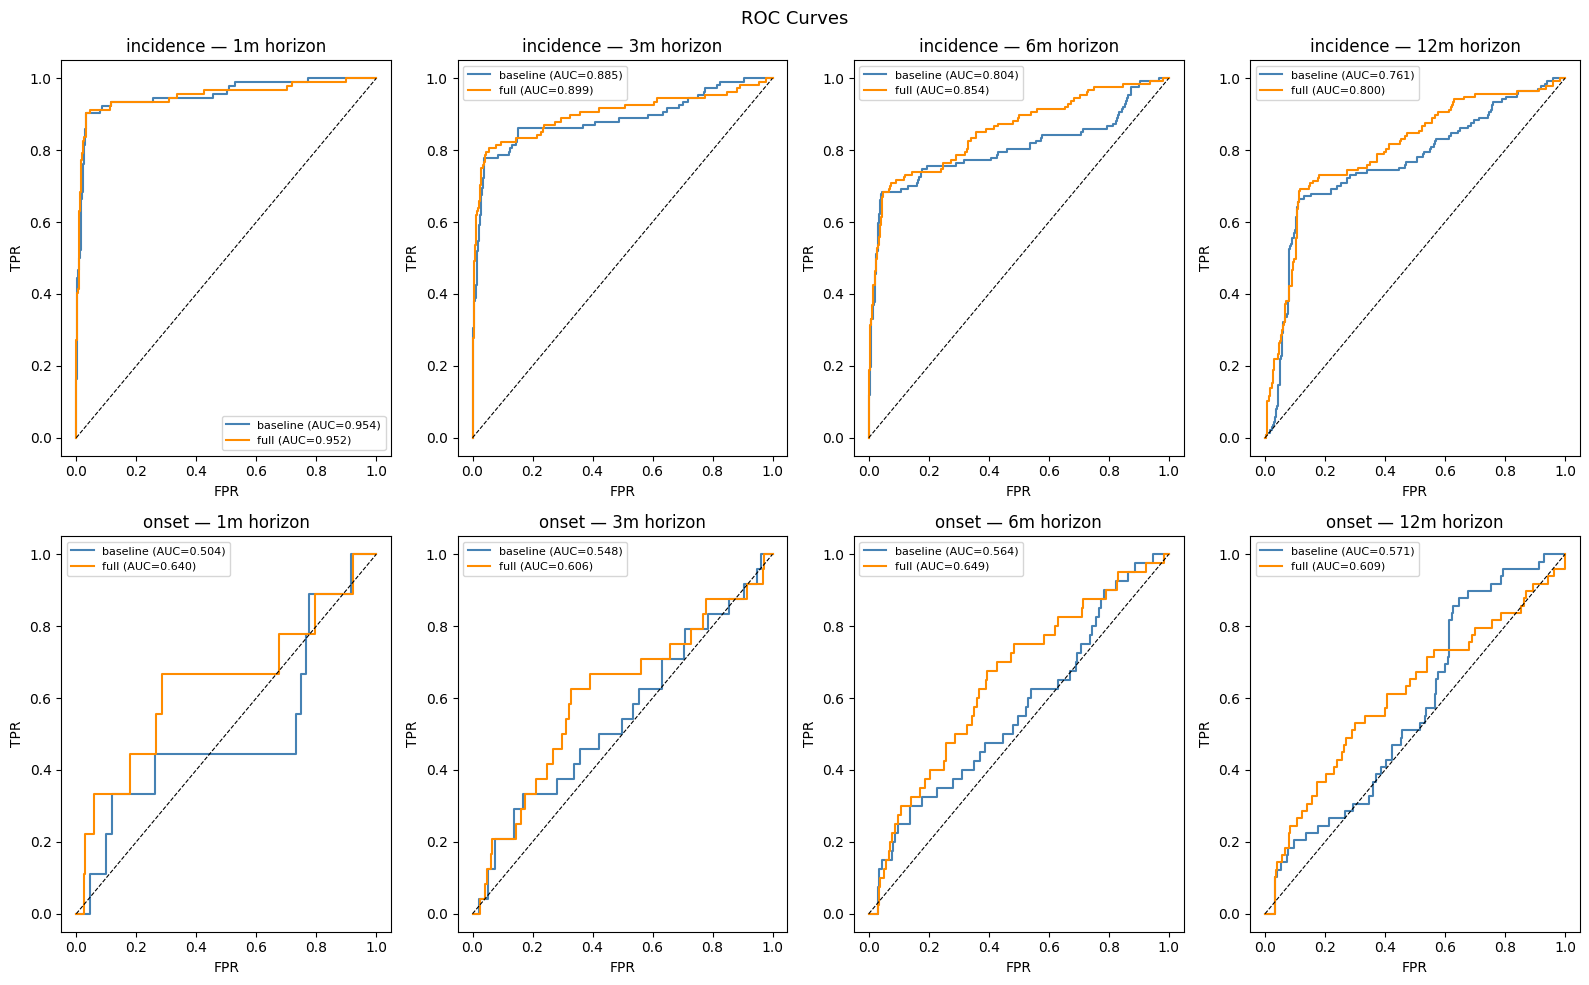

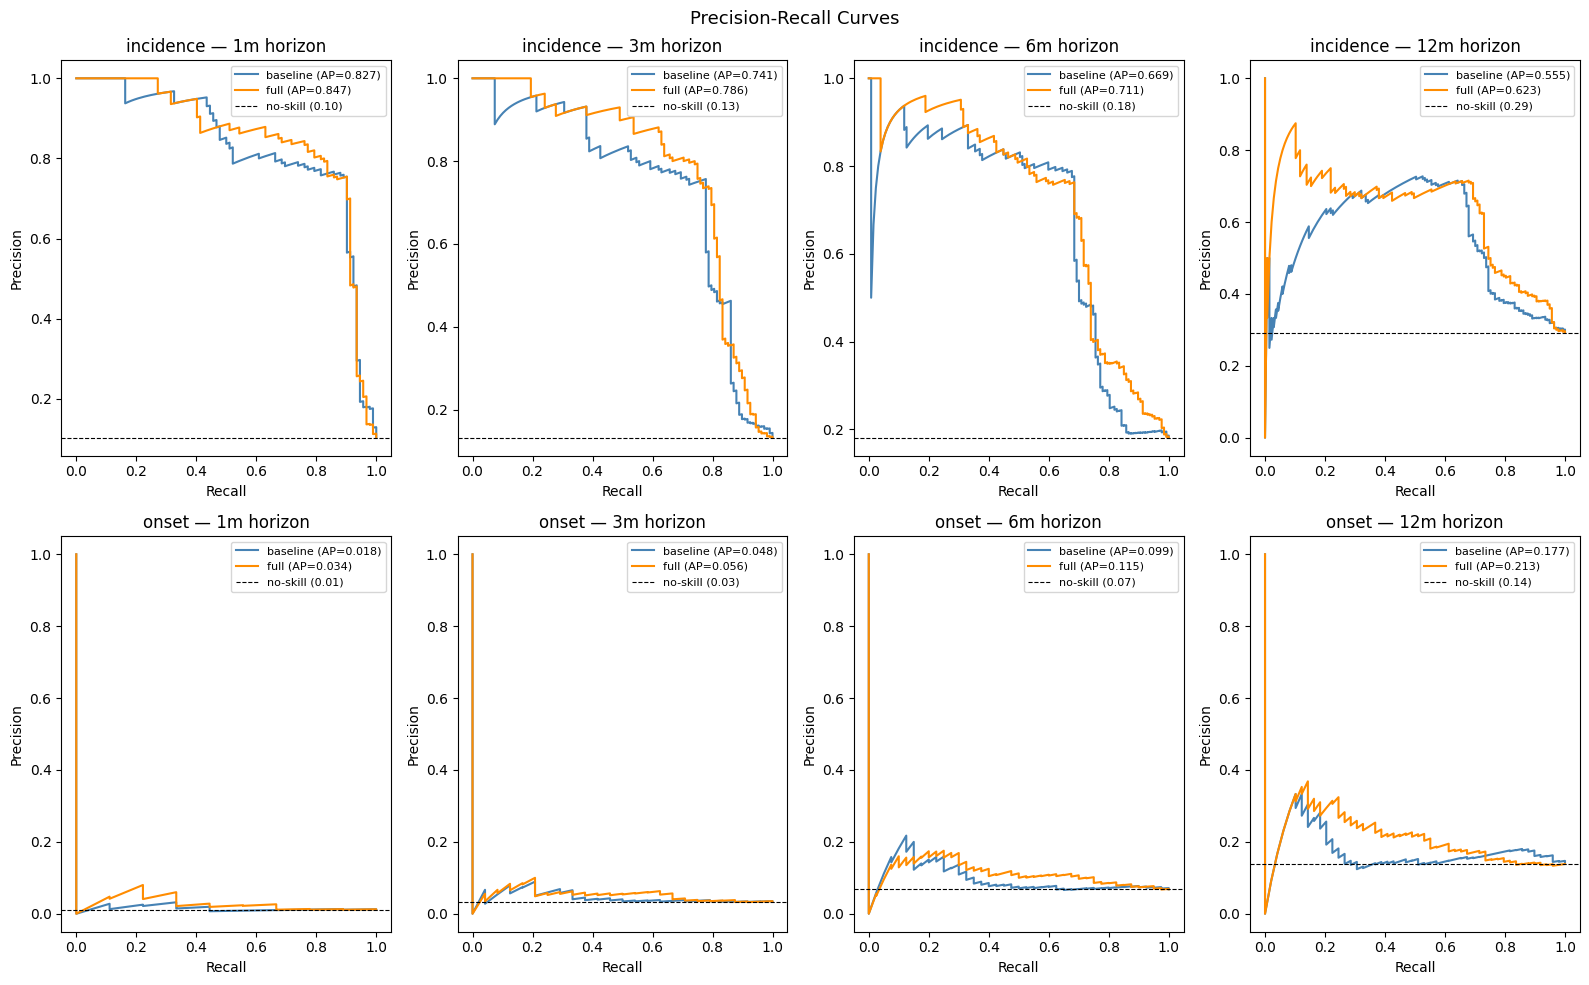

In [60]:
from sklearn.metrics import roc_curve, roc_auc_score, precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, len(HORIZONS), figsize=(16, 10))

for j, h in enumerate(HORIZONS):
    for target_name, row in [('incidence', 0), ('onset', 1)]:
        ax = axes[row, j]

        for model_name, color in [('baseline', 'steelblue'), ('full', 'darkorange')]:
            df_res = results[(h, model_name, target_name)].dropna(subset=['y_true', 'pred_prob'])
            y_true = df_res['y_true'].astype(float)
            y_pred = df_res['pred_prob']

            fpr, tpr, _ = roc_curve(y_true, y_pred)
            auc = roc_auc_score(y_true, y_pred)
            ax.plot(fpr, tpr, color=color, label=f'{model_name} (AUC={auc:.3f})')

        ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8)
        ax.set_title(f'{target_name} — {h}m horizon')
        ax.set_xlabel('FPR')
        ax.set_ylabel('TPR')
        ax.legend(fontsize=8)

plt.suptitle('ROC Curves', fontsize=13)
plt.tight_layout()
plt.show()

# Precision-Recall
fig, axes = plt.subplots(2, len(HORIZONS), figsize=(16, 10))

for j, h in enumerate(HORIZONS):
    for target_name, row in [('incidence', 0), ('onset', 1)]:
        ax = axes[row, j]

        for model_name, color in [('baseline', 'steelblue'), ('full', 'darkorange')]:
            df_res = results[(h, model_name, target_name)].dropna(subset=['y_true', 'pred_prob'])
            y_true = df_res['y_true'].astype(float)
            y_pred = df_res['pred_prob']

            precision, recall, _ = precision_recall_curve(y_true, y_pred)
            ap = average_precision_score(y_true, y_pred)
            ax.plot(recall, precision, color=color, label=f'{model_name} (AP={ap:.3f})')

        baseline_rate = y_true.mean()
        ax.axhline(baseline_rate, color='k', linestyle='--', linewidth=0.8, label=f'no-skill ({baseline_rate:.2f})')
        ax.set_title(f'{target_name} — {h}m horizon')
        ax.set_xlabel('Recall')
        ax.set_ylabel('Precision')
        ax.legend(fontsize=8)

plt.suptitle('Precision-Recall Curves', fontsize=13)
plt.tight_layout()
plt.show()


Feature importance/SHAP

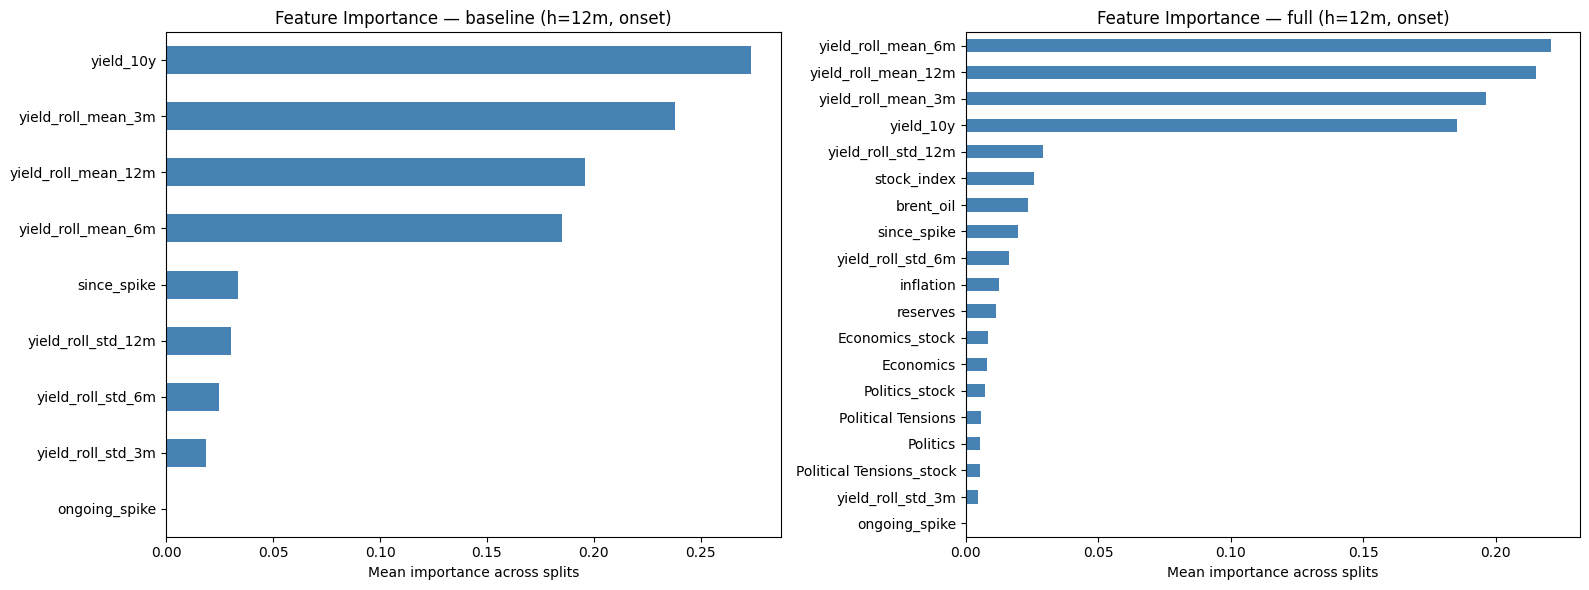

In [61]:
# Average feature importance across all splits for the full model
# Using the last horizon (12m) onset as the reference — most interesting for early warning

H = 12
TARGET = 'onset'

fitted_estimators = {}
for model_name, feat_cols in [('baseline', baseline_cols), ('full', full_cols)]:
    cv = build_cv(gap=H)
    X = df[feat_cols]
    y = df[f'ons_h{H}'].astype(float)
    _, estimators = cross_val_fit_predict(
        estimator=RandomForestClassifier(max_depth=4, max_features=0.2, min_samples_leaf=100, random_state=42),
        X=X, y=y, cv=cv, method='predict_proba', drop_na_in_y=True
    )
    fitted_estimators[model_name] = (estimators, feat_cols)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, (model_name, (estimators, feat_cols)) in zip(axes, fitted_estimators.items()):
    importances = np.mean([e.feature_importances_ for e in estimators], axis=0)
    imp_df = pd.Series(importances, index=feat_cols).sort_values(ascending=True)

    imp_df.plot(kind='barh', ax=ax, color='steelblue')
    ax.set_title(f'Feature Importance — {model_name} (h={H}m, {TARGET})')
    ax.set_xlabel('Mean importance across splits')

plt.tight_layout()
plt.show()
